In [1]:
from ucimlrepo import fetch_ucirepo 
air_quality = fetch_ucirepo(id=360) 

X = air_quality.data.features 
y = air_quality.data.targets 
  
print(air_quality.metadata) 
print(air_quality.variables) 

{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

# Wstępne przetwarzanie danych

## Zamiana wartości -200 na NaN

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

df = X.copy()
print(f"Kształt danych: {df.shape}")
print(f"Kolumny: {list(df.columns)}")

df = df.replace(-200, np.nan)
missing_counts = df.isnull().sum()
print(f"\nBrakujące wartości w kolumnach:")
if missing_counts.sum() > 0:
    print(missing_counts[missing_counts > 0])
else:
    print("Brak brakujących wartości")


Kształt danych: (9357, 15)
Kolumny: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

Brakujące wartości w kolumnach:
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


## Ekstrakcja miesiąca jako zmiennej kategorycznej

In [3]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
df['Month'] = df['Date'].dt.month

print("Rozkład próbek według miesięcy:")
print(df['Month'].value_counts().sort_index())


Rozkład próbek według miesięcy:
Month
1.0     312
2.0     312
3.0     312
4.0     303
5.0     288
6.0     288
7.0     288
8.0     288
9.0     288
10.0    294
11.0    312
12.0    312
Name: count, dtype: int64


## Utworzenie zmiennej zależnej

Sumę koncentracji liczymy przed skalowaniem, bo suma koncentracji ma rzeczywiste znaczenie (całkowite zanieczyszczenie), zmienna zależna nie powinna być skalowana w regresji, skalowanie jest stosowane tylko do zmiennych objaśniających, nie do zmiennej zależnej, suma po skalowaniu straciłaby sens fizyczny i jednostki

In [4]:
gt_columns = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
y_target = df[gt_columns].sum(axis=1)

print(f"Zmienna target: suma {gt_columns}")
print(f"\nStatystyki zmiennej target:")
print(f"  Liczba obserwacji: {y_target.count()}")
print(f"  Średnia:  {y_target.mean():.2f}")
print(f"  Odch. std: {y_target.std():.2f}")
print(f"  Minimum:  {y_target.min():.2f}")
print(f"  Maksimum: {y_target.max():.2f}")


Zmienna target: suma ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

Statystyki zmiennej target:
  Liczba obserwacji: 9357
  Średnia:  329.72
  Odch. std: 289.06
  Minimum:  0.00
  Maksimum: 1808.70


## Usunięcie zbędnych zmiennych

Trzeba usunąć: 
- wszystkie kolumny GT (CO(GT), NMHC(GT), C6H6(GT), NOx(GT), NO2(GT)), ponieważ one są wyciekiem danych i są to pomiary referencyjne,
- datę i godzinę, ponieważ nie traktujemy zbioru jako serii czasowej,
- wilgotność bezwzględną, ponieważ jest funkcją temperatury i wilgotność względnej.

In [5]:
# Usunięcie zmiennych
exclude = ['Date', 'Time', 'AH', 'CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

print("Usuwane zmienne:")
for col in exclude:
    if col in df.columns:
        print(f"  - {col}")

df = df.drop(columns=exclude)

print(f"\nPozostałe cechy (features): {list(df.columns)}")


Usuwane zmienne:
  - Date
  - Time
  - AH
  - CO(GT)
  - NMHC(GT)
  - C6H6(GT)
  - NOx(GT)
  - NO2(GT)

Pozostałe cechy (features): ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'Month']


## Usunięcie wierszy z brakującymi wartościami

Jest na tyle wyników, że można sobie pozwolić na usunięcie niekompletnych.

In [6]:
# Usunięcie wierszy z brakami danych
print(f"Liczba wierszy przed usunięciem: {len(df)}")

valid_idx = ~df.isnull().any(axis=1)
df = df[valid_idx]
y_target = y_target[valid_idx]

print(f"Liczba wierszy po usunięciu:   {len(df)}")
print(f"Usunięto wierszy:              {(~valid_idx).sum()}")


Liczba wierszy przed usunięciem: 9357
Liczba wierszy po usunięciu:   3418
Usunięto wierszy:              5939


## Skalowanie cech

In [7]:
continuous_features = [col for col in df.columns if col != 'Month']

print(f"Cechy do skalowania: {continuous_features}")
print(f"Nieskalowane:       ['Month']")

scaler = StandardScaler()
df[continuous_features] = scaler.fit_transform(df[continuous_features])

print("\nZastosowano StandardScaler:")
print("  Każda cecha ma teraz: średnia ≈ 0, odch. std. ≈ 1")

X_processed = df

print(f"\n{'='*70}")
print("PREPROCESSING ZAKOŃCZONY")
print(f"{'='*70}")
print(f"Kształt X_processed: {X_processed.shape}")
print(f"Kształt y_target:    {y_target.shape}")
print(f"Cechy:               {list(X_processed.columns)}")
print(f"{'='*70}")


Cechy do skalowania: ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH']
Nieskalowane:       ['Month']

Zastosowano StandardScaler:
  Każda cecha ma teraz: średnia ≈ 0, odch. std. ≈ 1

PREPROCESSING ZAKOŃCZONY
Kształt X_processed: (3418, 8)
Kształt y_target:    (3418,)
Cechy:               ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'Month']


## Wizualizacja wyników preprocessingu


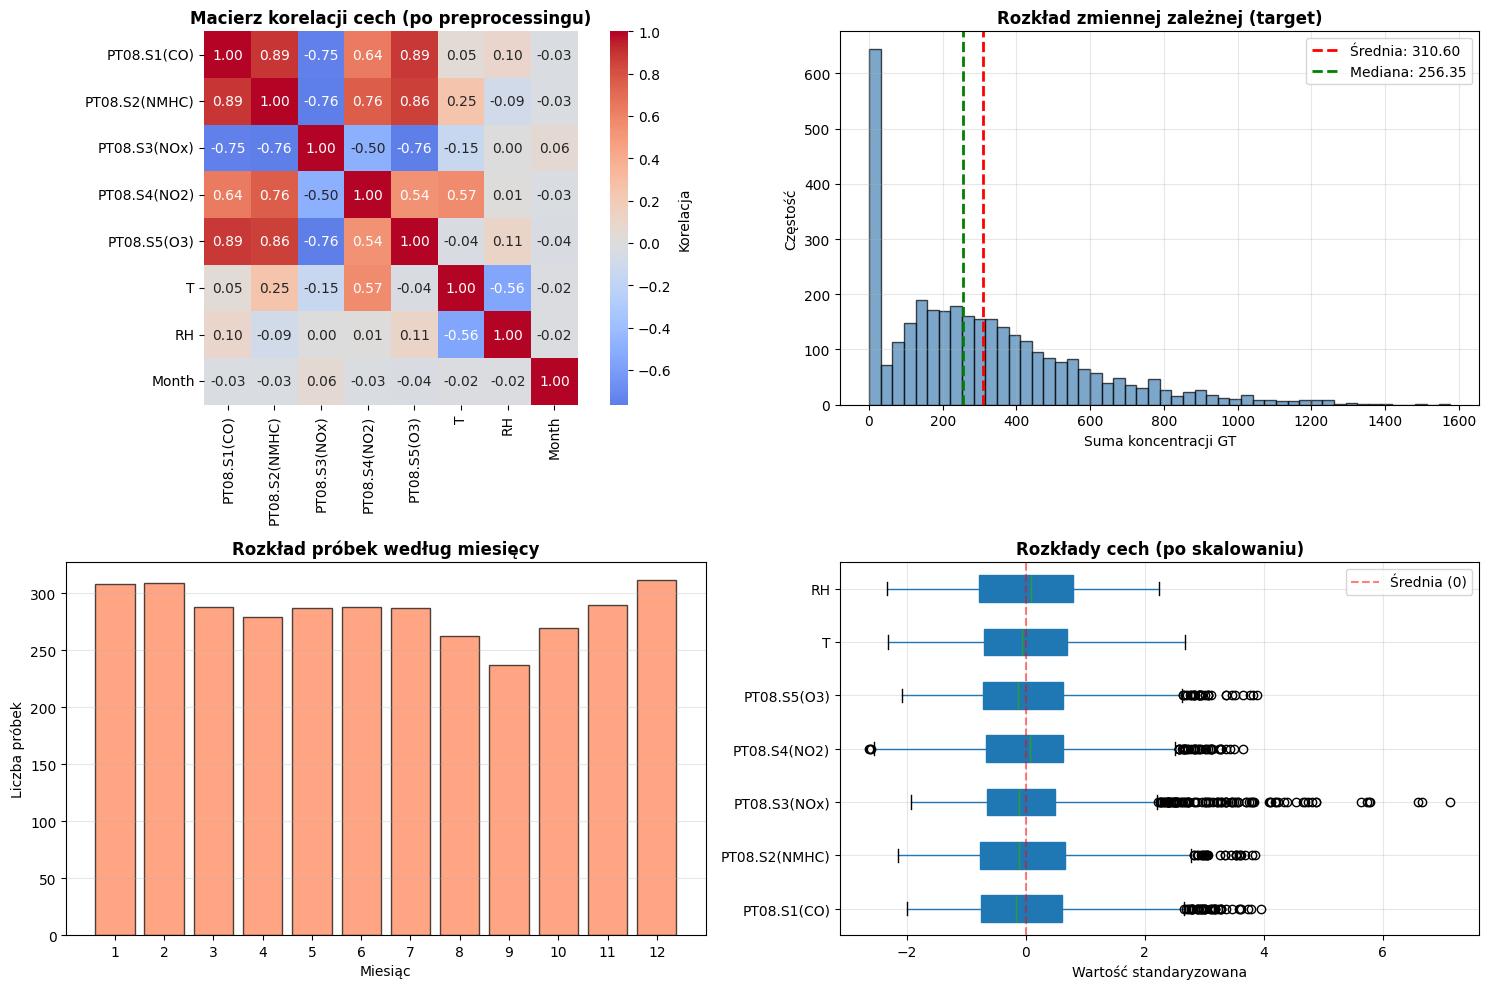

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Macierz korelacji
corr = X_processed.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[0,0], square=True, cbar_kws={'label': 'Korelacja'})
axes[0,0].set_title('Macierz korelacji cech (po preprocessingu)', fontsize=12, fontweight='bold')

# 2. Rozkład zmiennej target
axes[0,1].hist(y_target, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0,1].axvline(y_target.mean(), color='red', linestyle='--', linewidth=2,
                  label=f'Średnia: {y_target.mean():.2f}')
axes[0,1].axvline(y_target.median(), color='green', linestyle='--', linewidth=2,
                  label=f'Mediana: {y_target.median():.2f}')
axes[0,1].set_xlabel('Suma koncentracji GT', fontsize=10)
axes[0,1].set_ylabel('Częstość', fontsize=10)
axes[0,1].set_title('Rozkład zmiennej zależnej (target)', fontsize=12, fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# 3. Rozkład według miesięcy
month_counts = X_processed['Month'].value_counts().sort_index()
axes[1,0].bar(month_counts.index, month_counts.values, edgecolor='black', alpha=0.7, color='coral')
axes[1,0].set_xlabel('Miesiąc', fontsize=10)
axes[1,0].set_ylabel('Liczba próbek', fontsize=10)
axes[1,0].set_title('Rozkład próbek według miesięcy', fontsize=12, fontweight='bold')
axes[1,0].set_xticks(range(1, 13))
axes[1,0].grid(axis='y', alpha=0.3)

# 4. Rozkłady cech (box plot)
X_processed[continuous_features].boxplot(ax=axes[1,1], vert=False, patch_artist=True)
axes[1,1].set_xlabel('Wartość standaryzowana', fontsize=10)
axes[1,1].set_title('Rozkłady cech (po skalowaniu)', fontsize=12, fontweight='bold')
axes[1,1].axvline(0, color='red', linestyle='--', alpha=0.5, label='Średnia (0)')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Modelowanie

## Podział danych na zbiór treningowy i testowy


In [9]:
from sklearn.model_selection import train_test_split

# Podział 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_target, test_size=0.2, random_state=42
)

print(f"Zbiór treningowy: {X_train.shape}")
print(f"Zbiór testowy:    {X_test.shape}")


Zbiór treningowy: (2734, 8)
Zbiór testowy:    (684, 8)


## Definicja modeli

In [10]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, HuberRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time

# Definicja modeli i ich parametrów do przeszukiwania
models = {
    'Linear': {
        'model': LinearRegression(),
        'params': {}
    },
    'Lasso (L1)': {
        'model': Lasso(max_iter=10000, random_state=42),
        'params': {
            'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
        }
    },
    'Ridge (L2)': {
        'model': Ridge(random_state=42),
        'params': {
            'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
        }
    },
    'Huber': {
        'model': HuberRegressor(max_iter=1000),
        'params': {
            'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0],
            'epsilon': [1.1, 1.35, 1.5, 2.0]
        }
    }
}

## GridSearchCV

In [11]:
results = {}

for name, config in models.items():
    print("=" * 70)
    print(f"Trenowanie: {name}")
    print("=" * 70)
    
    start_time = time.time()
    
    if config['params']:  # Jeśli są parametry do tuningu
        grid = GridSearchCV(
            config['model'],
            config['params'],
            cv=5,
            scoring='neg_mean_squared_error',
            n_jobs=1,
            verbose=1
        )
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        print(f"Najlepsze parametry: {grid.best_params_}")
    else:  # LinearRegression - brak parametrów
        best_model = config['model']
        best_model.fit(X_train, y_train)
        print("Model bez parametrów do tuningu")
    
    train_time = time.time() - start_time
    
    # Predykcje
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    
    # Metryki
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    results[name] = {
        'model': best_model,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_time': train_time,
        'params': grid.best_params_ if config['params'] else 'default'
    }
    
    print(f"Wyniki:")
    print(f"  RMSE train: {train_rmse:.4f}")
    print(f"  RMSE test:  {test_rmse:.4f}")
    print(f"  MAE train:  {train_mae:.4f}")
    print(f"  MAE test:   {test_mae:.4f}")
    print(f"  Czas:       {train_time:.2f}s")

print("=" * 70)
print("TRENING ZAKOŃCZONY")
print("=" * 70)



Trenowanie: Linear
Model bez parametrów do tuningu
Wyniki:
  RMSE train: 166.0344
  RMSE test:  174.5668
  MAE train:  113.5070
  MAE test:   117.6461
  Czas:       0.00s
Trenowanie: Lasso (L1)
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Najlepsze parametry: {'alpha': 0.1}
Wyniki:
  RMSE train: 166.0355
  RMSE test:  174.5522
  MAE train:  113.5072
  MAE test:   117.6215
  Czas:       0.18s
Trenowanie: Ridge (L2)
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Najlepsze parametry: {'alpha': 1.0}
Wyniki:
  RMSE train: 166.0347
  RMSE test:  174.5481
  MAE train:  113.5192
  MAE test:   117.6377
  Czas:       0.14s
Trenowanie: Huber
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Najlepsze parametry: {'alpha': 0.1, 'epsilon': 2.0}
Wyniki:
  RMSE train: 166.9152
  RMSE test:  174.5141
  MAE train:  111.0061
  MAE test:   114.3413
  Czas:       3.09s
TRENING ZAKOŃCZONY


## Porównanie wyników modeli


In [12]:
# Zebranie wyników w DataFrame
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'RMSE_train': [r['train_rmse'] for r in results.values()],
    'RMSE_test': [r['test_rmse'] for r in results.values()],
    'MAE_train': [r['train_mae'] for r in results.values()],
    'MAE_test': [r['test_mae'] for r in results.values()],
    'Czas [s]': [r['train_time'] for r in results.values()],
    'Parametry': [str(r['params']) for r in results.values()]
})

print(results_df.to_string(index=False))

# Najlepszy model
best_model_name = results_df.loc[results_df['RMSE_test'].idxmin(), 'Model']
print(f"\nNajlepszy model (najniższe RMSE test): {best_model_name}")


     Model  RMSE_train  RMSE_test  MAE_train   MAE_test  Czas [s]                      Parametry
    Linear  166.034389 174.566787 113.506961 117.646120  0.003361                        default
Lasso (L1)  166.035522 174.552233 113.507241 117.621520  0.178264                 {'alpha': 0.1}
Ridge (L2)  166.034717 174.548078 113.519230 117.637701  0.144398                 {'alpha': 1.0}
     Huber  166.915174 174.514126 111.006107 114.341341  3.094138 {'alpha': 0.1, 'epsilon': 2.0}

Najlepszy model (najniższe RMSE test): Huber


## Wizualizacja porównania modeli


/tmp/ipykernel_151291/2799828515.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(results_df['Model'], rotation=45, ha='right')
/tmp/ipykernel_151291/2799828515.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(results_df['Model'], rotation=45, ha='right')


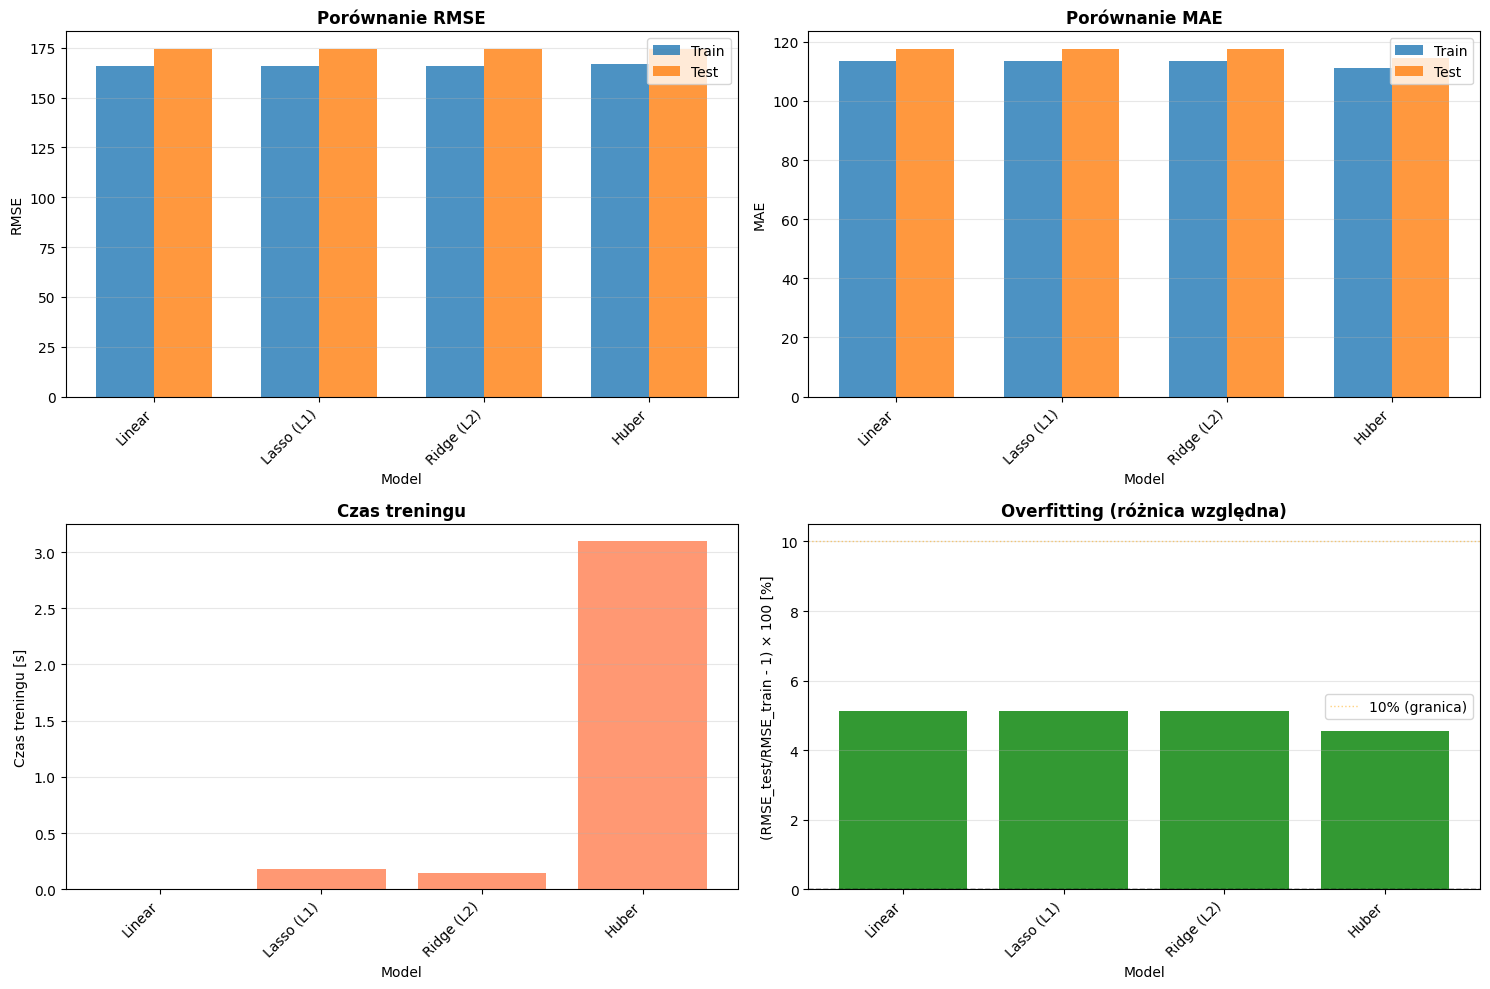

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. RMSE comparison
ax1 = axes[0, 0]
x = np.arange(len(results_df))
width = 0.35
ax1.bar(x - width/2, results_df['RMSE_train'], width, label='Train', alpha=0.8)
ax1.bar(x + width/2, results_df['RMSE_test'], width, label='Test', alpha=0.8)
ax1.set_xlabel('Model')
ax1.set_ylabel('RMSE')
ax1.set_title('Porównanie RMSE', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. MAE comparison
ax2 = axes[0, 1]
ax2.bar(x - width/2, results_df['MAE_train'], width, label='Train', alpha=0.8)
ax2.bar(x + width/2, results_df['MAE_test'], width, label='Test', alpha=0.8)
ax2.set_xlabel('Model')
ax2.set_ylabel('MAE')
ax2.set_title('Porównanie MAE', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Training time
ax3 = axes[1, 0]
ax3.bar(results_df['Model'], results_df['Czas [s]'], alpha=0.8, color='coral')
ax3.set_xlabel('Model')
ax3.set_ylabel('Czas treningu [s]')
ax3.set_title('Czas treningu', fontweight='bold')
ax3.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

# 4. Overfitting check (RATIO-BASED)
ax4 = axes[1, 1]
overfit_ratio = (results_df['RMSE_test'] / results_df['RMSE_train'] - 1) * 100
colors = ['green' if x < 10 else 'orange' if x < 20 else 'red' for x in overfit_ratio]
ax4.bar(results_df['Model'], overfit_ratio, alpha=0.8, color=colors)
ax4.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax4.axhline(y=10, color='orange', linestyle=':', linewidth=1, alpha=0.5, label='10% (granica)')
ax4.set_xlabel('Model')
ax4.set_ylabel('(RMSE_test/RMSE_train - 1) × 100 [%]')
ax4.set_title('Overfitting (różnica względna)', fontweight='bold')
ax4.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Wizualizacja współczynników


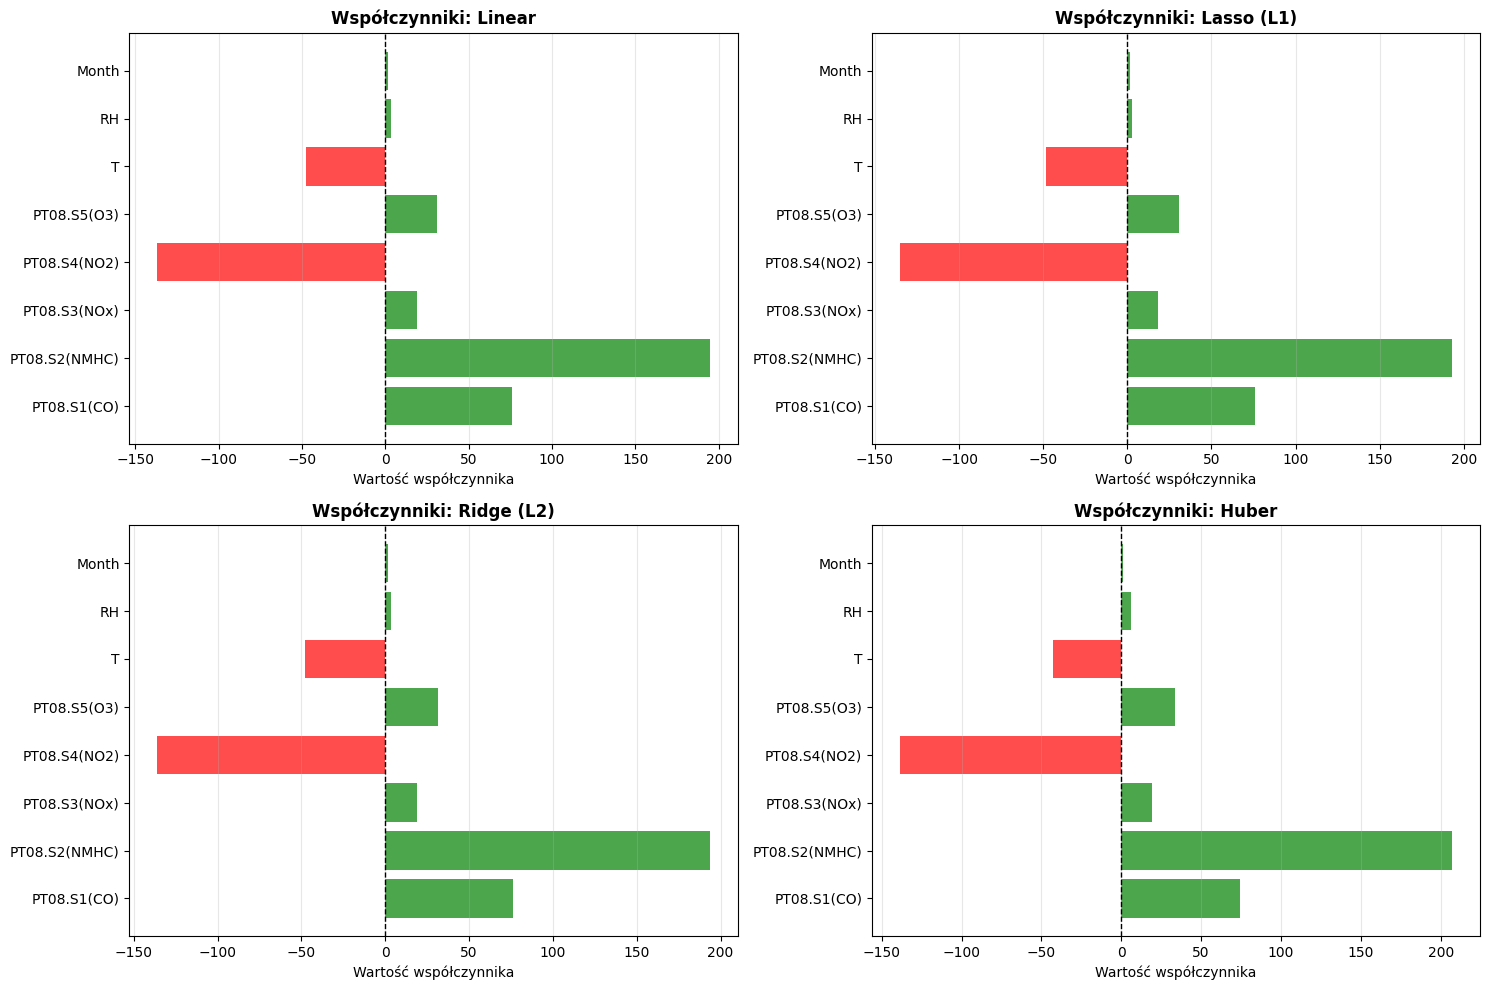


Wartości współczynników:
                 Linear  Lasso (L1)  Ridge (L2)     Huber
PT08.S1(CO)     76.0097     75.8436     76.0619   74.0548
PT08.S2(NMHC)  194.7065    193.1629    193.5887  207.3023
PT08.S3(NOx)    19.1324     18.3668     18.8937   19.2719
PT08.S4(NO2)  -136.8241   -135.3734   -136.0276 -138.7603
PT08.S5(O3)     30.9111     30.9701     31.2342   33.5239
T              -47.2643    -48.1127    -47.6545  -42.7398
RH               3.7010      2.9740      3.3259    6.1647
Month            1.4949      1.4913      1.4967    1.2945


In [14]:
# Zbieranie współczynników
coefficients = {}
for name, res in results.items():
    model = res['model']
    if hasattr(model, 'coef_'):
        coefficients[name] = model.coef_

# Wizualizacja
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

feature_names = X_processed.columns

for idx, (name, coefs) in enumerate(coefficients.items()):
    ax = axes[idx]
    colors = ['red' if c < 0 else 'green' for c in coefs]
    ax.barh(feature_names, coefs, color=colors, alpha=0.7)
    ax.set_xlabel('Wartość współczynnika')
    ax.set_title(f'Współczynniki: {name}', fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Wyświetlenie numerycznych wartości
coef_df = pd.DataFrame(coefficients, index=feature_names)
print("\nWartości współczynników:")
print(coef_df.round(4))


## Analiza wpływu regularyzacji

Badamy jak wartość parametru alpha wpływa na współczynniki i błąd


In [15]:
# Testowanie różnych wartości alpha
alphas = np.logspace(-3, 3, 50)

lasso_scores = []
ridge_scores = []
lasso_coefs = []
ridge_coefs = []

X_tr, X_te, y_tr, y_te = train_test_split(X_processed, y_target, test_size=0.2, random_state=42)

for alpha in alphas:
    # Lasso
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    lasso.fit(X_tr, y_tr)
    lasso_scores.append(mean_squared_error(y_te, lasso.predict(X_te)))
    lasso_coefs.append(lasso.coef_)
    
    # Ridge
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_tr, y_tr)
    ridge_scores.append(mean_squared_error(y_te, ridge.predict(X_te)))
    ridge_coefs.append(ridge.coef_)

lasso_coefs = np.array(lasso_coefs)
ridge_coefs = np.array(ridge_coefs)


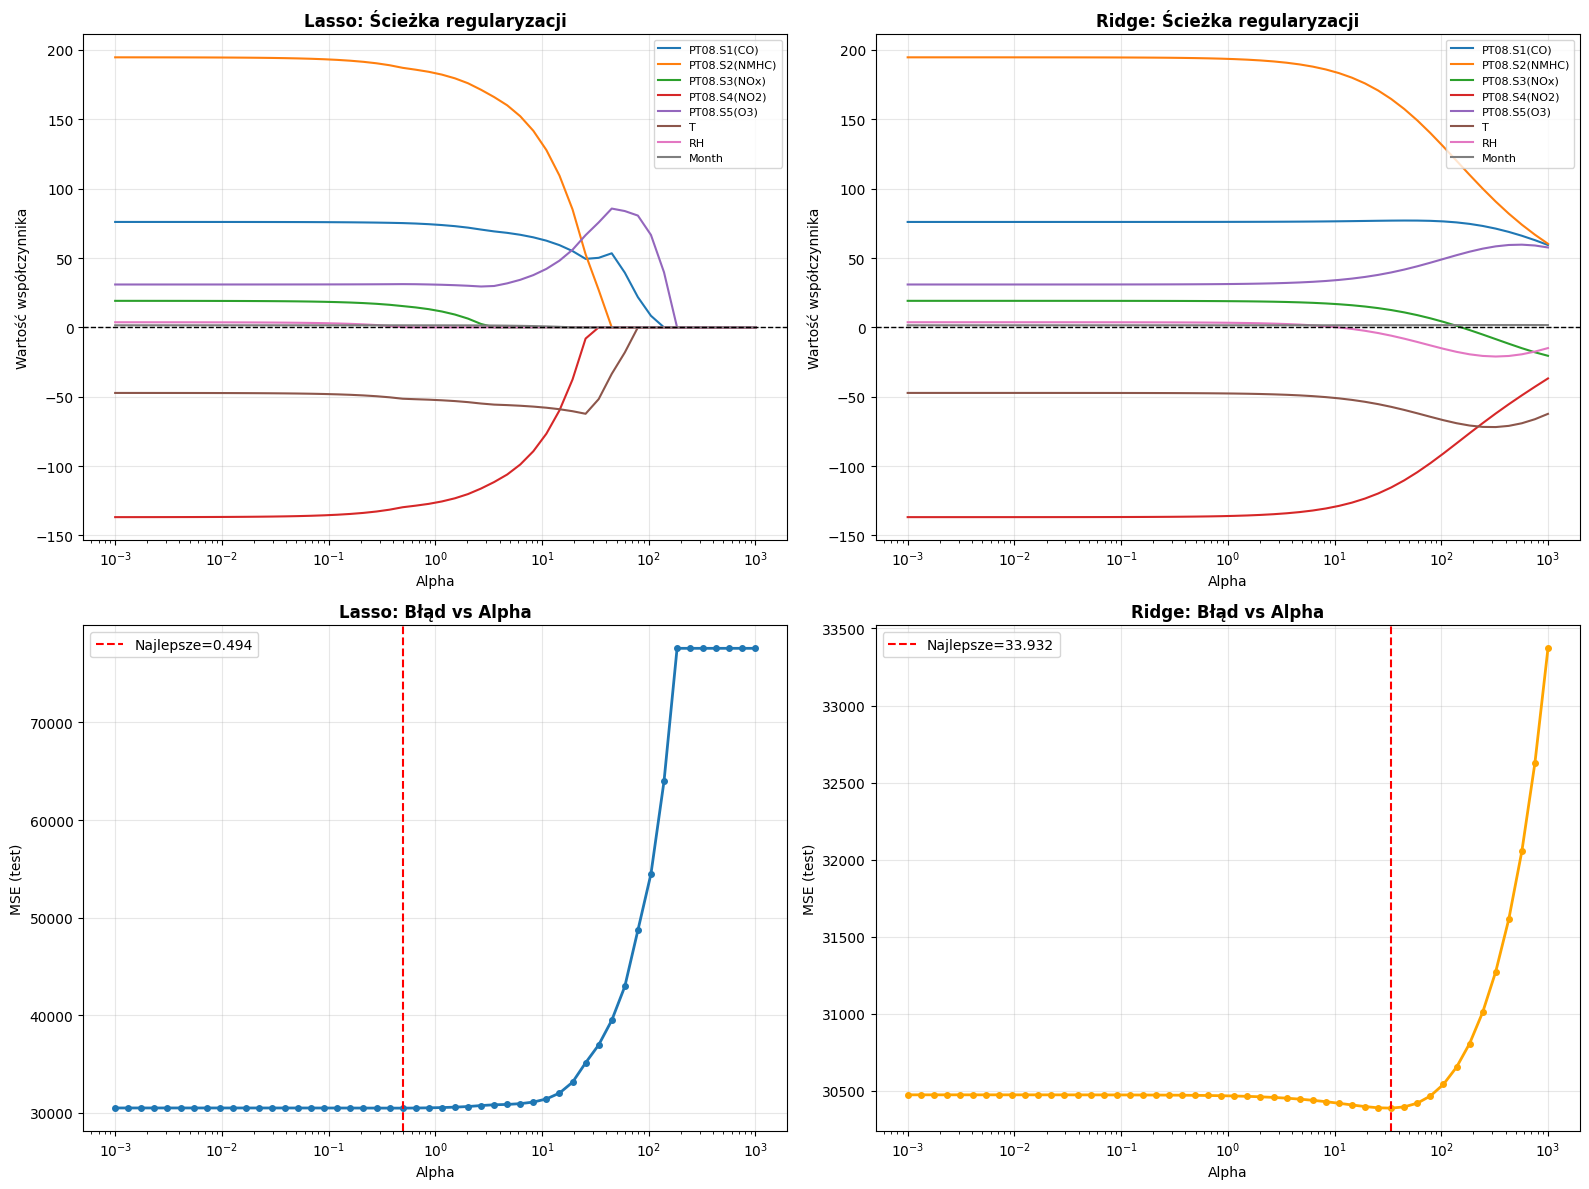

Najlepsze alpha dla Lasso: 0.4942
Najlepsze alpha dla Ridge: 33.9322


In [16]:
# Wizualizacja regularization path
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Lasso path
ax1 = axes[0, 0]
for i in range(lasso_coefs.shape[1]):
    ax1.plot(alphas, lasso_coefs[:, i], label=X_processed.columns[i])
ax1.set_xscale('log')
ax1.set_xlabel('Alpha')
ax1.set_ylabel('Wartość współczynnika')
ax1.set_title('Lasso: Ścieżka regularyzacji', fontweight='bold')
ax1.legend(loc='best', fontsize=8)
ax1.grid(alpha=0.3)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1)

# 2. Ridge path
ax2 = axes[0, 1]
for i in range(ridge_coefs.shape[1]):
    ax2.plot(alphas, ridge_coefs[:, i], label=X_processed.columns[i])
ax2.set_xscale('log')
ax2.set_xlabel('Alpha')
ax2.set_ylabel('Wartość współczynnika')
ax2.set_title('Ridge: Ścieżka regularyzacji', fontweight='bold')
ax2.legend(loc='best', fontsize=8)
ax2.grid(alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)

# 3. Lasso MSE
ax3 = axes[1, 0]
ax3.plot(alphas, lasso_scores, 'o-', linewidth=2, markersize=4)
ax3.set_xscale('log')
ax3.set_xlabel('Alpha')
ax3.set_ylabel('MSE (test)')
ax3.set_title('Lasso: Błąd vs Alpha', fontweight='bold')
ax3.grid(alpha=0.3)
best_alpha_lasso = alphas[np.argmin(lasso_scores)]
ax3.axvline(x=best_alpha_lasso, color='red', linestyle='--', 
            label=f'Najlepsze={best_alpha_lasso:.3f}')
ax3.legend()

# 4. Ridge MSE
ax4 = axes[1, 1]
ax4.plot(alphas, ridge_scores, 'o-', linewidth=2, markersize=4, color='orange')
ax4.set_xscale('log')
ax4.set_xlabel('Alpha')
ax4.set_ylabel('MSE (test)')
ax4.set_title('Ridge: Błąd vs Alpha', fontweight='bold')
ax4.grid(alpha=0.3)
best_alpha_ridge = alphas[np.argmin(ridge_scores)]
ax4.axvline(x=best_alpha_ridge, color='red', linestyle='--',
            label=f'Najlepsze={best_alpha_ridge:.3f}')
ax4.legend()

plt.tight_layout()
plt.show()

print(f"Najlepsze alpha dla Lasso: {best_alpha_lasso:.4f}")
print(f"Najlepsze alpha dla Ridge: {best_alpha_ridge:.4f}")


## Wnioski końcowe

### RMSE vs MAE:
- RMSE bardziej penalizuje duże błędy
- MAE bardziej odporny na outliery
- Wybór zależy od aplikacji

### Regularyzacja:
- **L1 (Lasso)**: zeruje współczynniki, selekcja cech
- **L2 (Ridge)**: zmniejsza współczynniki równomiernie
- Parametr alpha kontroluje siłę regularyzacji

### Czas treningu:
- LinearRegression najszybszy
- GridSearchCV zwiększa czas (przeszukiwanie parametrów)

## Wpływ preprocessingu z Pipeline

Porównanie:
1. **Baseline** - bez AH, z Month, ze skalowaniem
2. **Z AH** - pozostawienie skorelowanej cechy
3. **Bez Month** - usunięcie zmiennej kategorycznej
4. **Bez skalowania** - surowe wartości czujników
5. **Tylko czujniki** - bez zmiennych środowiskowych (T, RH, Month)


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Przygotowanie danych bazowych
df_raw = X.copy()
df_raw = df_raw.replace(-200, np.nan)
df_raw['Date'] = pd.to_datetime(df_raw['Date'], format='%d/%m/%Y', errors='coerce')
df_raw['Month'] = df_raw['Date'].dt.month

gt_columns = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
y_full = df_raw[gt_columns].sum(axis=1)

# Usuń GT, Date, Time
df_raw = df_raw.drop(columns=['Date', 'Time'] + gt_columns)

# Usuń wiersze z NaN
valid_idx = ~df_raw.isnull().any(axis=1)
df_raw = df_raw[valid_idx]
y_full = y_full[valid_idx]

print(f"Dane bazowe: {df_raw.shape}")
print(f"Kolumny: {list(df_raw.columns)}")


Dane bazowe: (3418, 9)
Kolumny: ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Month']


In [18]:
# Definicja różnych wariantów Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer

class ColumnDropper(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X.drop(columns=self.columns, errors='ignore')

# Warianty Pipeline
pipelines = {
    'Baseline (nasza wersja)': Pipeline([
        ('drop_ah', ColumnDropper(['AH'])),
        ('scaler', StandardScaler())
    ]),
    
    'Z AH (wielokolinearność)': Pipeline([
        ('drop_month', ColumnDropper(['Month'])),
        ('scaler', StandardScaler())
    ]),
    
    'Bez Month (bez sezonowości)': Pipeline([
        ('drop_cols', ColumnDropper(['Month', 'AH'])),
        ('scaler', StandardScaler())
    ]),
    
    'Bez normalizacji': Pipeline([
        ('drop_ah', ColumnDropper(['AH'])),
        ('no_scale', FunctionTransformer(validate=False))
    ]),
    
    'Tylko czujniki PT08': Pipeline([
        ('drop_cols', ColumnDropper(['AH', 'Month', 'T', 'RH'])),
        ('scaler', StandardScaler())
    ])
}

In [19]:
# Testowanie każdego Pipeline z Ridge
from sklearn.model_selection import cross_val_score

pipeline_results = []

for name, pipeline in pipelines.items():
    print(f"\nTestowanie: {name}")
    
    # Split
    X_tr, X_te, y_tr, y_te = train_test_split(df_raw, y_full, test_size=0.2, random_state=42)
    
    # Pełny pipeline z modelem
    full_pipeline = Pipeline([
        ('preprocessing', pipeline),
        ('model', Ridge(alpha=1.0, random_state=42))
    ])
    
    # Cross-validation na zbiorze treningowym
    cv_scores = cross_val_score(full_pipeline, X_tr, y_tr, 
                                 cv=5, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores.mean())
    
    # Trening i test
    start = time.time()
    full_pipeline.fit(X_tr, y_tr)
    train_time = time.time() - start
    
    y_pred = full_pipeline.predict(X_te)
    test_rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    test_mae = mean_absolute_error(y_te, y_pred)
    
    # Liczba cech po preprocessingu
    X_transformed = pipeline.fit_transform(X_tr)
    n_features = X_transformed.shape[1]
    
    pipeline_results.append({
        'Wariant': name,
        'CV RMSE': cv_rmse,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Czas [s]': train_time,
        'Liczba cech': n_features
    })
    
    print(f"  CV RMSE: {cv_rmse:.2f}, Test RMSE: {test_rmse:.2f}, Cech: {n_features}")

# DataFrame z wynikami
pipeline_df = pd.DataFrame(pipeline_results)
print("\n" + "="*80)
print("Porównanie wariantów preprocessingu (Pipeline):")
print("="*80)
print(pipeline_df.to_string(index=False))

# Najlepszy wariant
best_idx = pipeline_df['Test RMSE'].idxmin()
best_variant = pipeline_df.loc[best_idx, 'Wariant']
print(f"\n Najlepszy wariant: {best_variant}")
print(f"  Test RMSE: {pipeline_df.loc[best_idx, 'Test RMSE']:.2f}")



Testowanie: Baseline (nasza wersja)
  CV RMSE: 166.78, Test RMSE: 174.55, Cech: 8

Testowanie: Z AH (wielokolinearność)
  CV RMSE: 166.08, Test RMSE: 172.73, Cech: 8

Testowanie: Bez Month (bez sezonowości)
  CV RMSE: 166.81, Test RMSE: 174.59, Cech: 7

Testowanie: Bez normalizacji
  CV RMSE: 166.78, Test RMSE: 174.57, Cech: 8

Testowanie: Tylko czujniki PT08
  CV RMSE: 170.03, Test RMSE: 177.98, Cech: 5

Porównanie wariantów preprocessingu (Pipeline):
                    Wariant    CV RMSE  Test RMSE   Test MAE  Czas [s]  Liczba cech
    Baseline (nasza wersja) 166.781319 174.547680 117.637647  0.003695            8
   Z AH (wielokolinearność) 166.084427 172.729617 115.934015  0.004055            8
Bez Month (bez sezonowości) 166.805902 174.594503 117.984814  0.003804            7
           Bez normalizacji 166.782296 174.566814 117.646113  0.002647            8
        Tylko czujniki PT08 170.031471 177.977601 119.298199  0.003993            5

 Najlepszy wariant: Z AH (wielokoline

## Wizualizacja wpływu preprocessingu


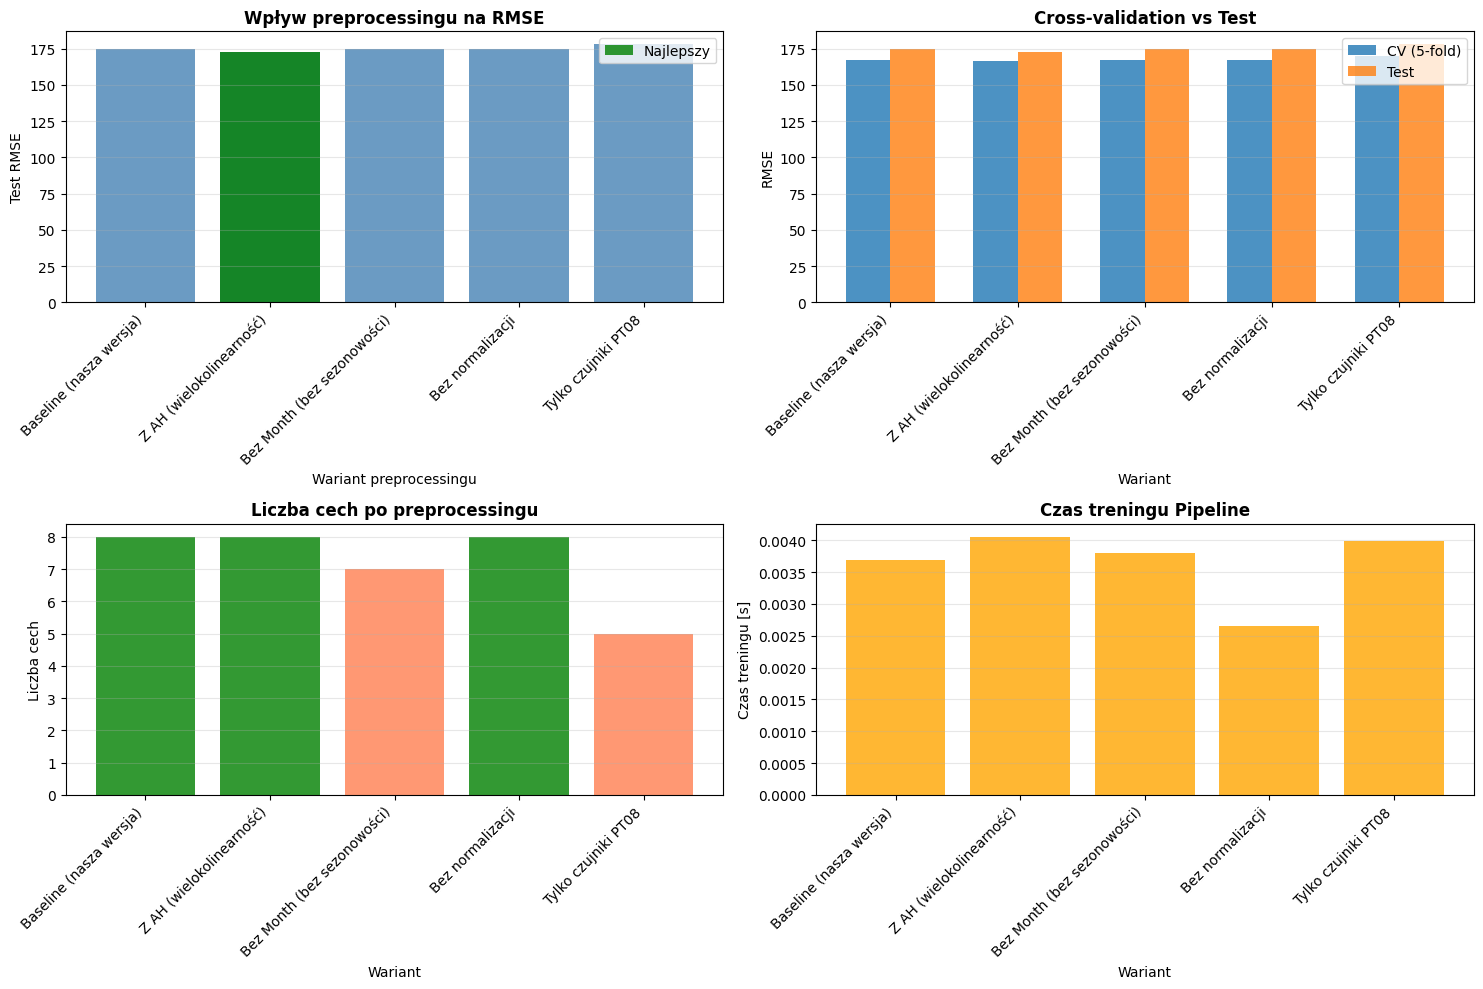

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. RMSE comparison
ax1 = axes[0, 0]
x = np.arange(len(pipeline_df))
ax1.bar(x, pipeline_df['Test RMSE'], alpha=0.8, color='steelblue')
ax1.set_xlabel('Wariant preprocessingu')
ax1.set_ylabel('Test RMSE')
ax1.set_title('Wpływ preprocessingu na RMSE', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(pipeline_df['Wariant'], rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)
# Mark best
best_idx = pipeline_df['Test RMSE'].idxmin()
ax1.bar(best_idx, pipeline_df.loc[best_idx, 'Test RMSE'], 
        alpha=0.8, color='green', label='Najlepszy')
ax1.legend()

# 2. CV vs Test RMSE
ax2 = axes[0, 1]
width = 0.35
ax2.bar(x - width/2, pipeline_df['CV RMSE'], width, label='CV (5-fold)', alpha=0.8)
ax2.bar(x + width/2, pipeline_df['Test RMSE'], width, label='Test', alpha=0.8)
ax2.set_xlabel('Wariant')
ax2.set_ylabel('RMSE')
ax2.set_title('Cross-validation vs Test', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(pipeline_df['Wariant'], rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Number of features
ax3 = axes[1, 0]
colors_feat = ['green' if f == pipeline_df.loc[best_idx, 'Liczba cech'] 
               else 'coral' for f in pipeline_df['Liczba cech']]
ax3.bar(x, pipeline_df['Liczba cech'], alpha=0.8, color=colors_feat)
ax3.set_xlabel('Wariant')
ax3.set_ylabel('Liczba cech')
ax3.set_title('Liczba cech po preprocessingu', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(pipeline_df['Wariant'], rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

# 4. Training time
ax4 = axes[1, 1]
ax4.bar(x, pipeline_df['Czas [s]'], alpha=0.8, color='orange')
ax4.set_xlabel('Wariant')
ax4.set_ylabel('Czas treningu [s]')
ax4.set_title('Czas treningu Pipeline', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(pipeline_df['Wariant'], rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Wnioski z analizy Pipeline

Wielokolinearność (AH):
Pozostawienie AH daje lepsze wyniki. Teoretycznie wielokolinearność utrudnia interpretację współczynników. Jednak Ridge z regularyzacją radzi sobie z tym problemem. AH niesie dodatkową informację mimo korelacji z RH i T. Widać, że w praktyce wielokolinearność nie zawsze szkodzi predykcji

Zmienna kategoryczna (Month):
Usunięcie Month prawie nie wpływa na wyniki (174.59 vs 174.55). Sezonowość może być ujęta w innych zmiennych (T, RH). Widać, że Month nie wnosi unikalnej informacji dla tego modelu.

Normalizacja:
Brak normalizacji nie pogarsza wyników (174.57 vs 174.55). Ridge automatycznie dostosowuje wagi do skal cech. W przeciwieństwie do Lasso, Ridge jest mniej wrażliwy na skalę. Widać, że dla Ridge normalizacja nie jest kluczowa (ale nadal dobra praktyka)

Tylko czujniki PT08:
Znaczące pogorszenie wyników (177.98 vs 174.55). Warunki meteorologiczne (T, RH) są istotne dla predykcji. Widać, że temperatura i wilgotność wpływają na dyspersję zanieczyszczeń

Pipeline vs ręczny preprocessing:
Pipeline zapewnia spójność między train/test. Unika data leakage (scaling fitowany na train, aplikowany na test). Łatwiejsze testowanie różnych wariantów. Widać, że Pipeline to best practice w ML, ułatwia eksperymenty

# Model liniowy z efektami mieszanymi (LME)

In [21]:
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM

# Przygotowanie danych dla statsmodels
df_lme = df_raw.copy()
df_lme = df_lme.drop(columns=['AH'], errors='ignore')  # Usuwamy AH (wielokolinearność)

# Zmiana nazw kolumn - usunięcie nawiasów
df_lme.columns = df_lme.columns.str.replace(r'[()]', '_', regex=True)
df_lme.columns = df_lme.columns.str.replace(r'\.', '_', regex=True)

df_lme['target'] = y_full.values

# Train/test split
X_tr_lme, X_te_lme, y_tr_lme, y_te_lme = train_test_split(
    df_lme.drop(columns=['target']), 
    df_lme['target'], 
    test_size=0.2, 
    random_state=42
)

# Łączymy z powrotem dla statsmodels (wymaga DataFrame)
train_lme = X_tr_lme.copy()
train_lme['target'] = y_tr_lme.values
test_lme = X_te_lme.copy()
test_lme['target'] = y_te_lme.values

print(f"Dane treningowe: {train_lme.shape}")
print(f"Dane testowe: {test_lme.shape}")
print(f"\nKolumny: {list(train_lme.columns)}")


Dane treningowe: (2734, 9)
Dane testowe: (684, 9)

Kolumny: ['PT08_S1_CO_', 'PT08_S2_NMHC_', 'PT08_S3_NOx_', 'PT08_S4_NO2_', 'PT08_S5_O3_', 'T', 'RH', 'Month', 'target']


In [22]:
# Model 1: LME z Month jako random effect
# Formula: target ~ fixed_effects, groups=Month oznacza random intercept dla każdego miesiąca
import time

features = [col for col in train_lme.columns if col not in ['target', 'Month']]
formula = f"target ~ {' + '.join(features)}"

print("="*80)
print("Model LME z Month jako random effect (random intercept)")
print("="*80)
print(f"Formula: {formula}")
print(f"Random effect: Month (random intercept)\n")

start = time.time()
# Normalizacja dla stabilności numerycznej
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_scaled = train_lme.copy()
test_scaled = test_lme.copy()

train_scaled[features] = scaler.fit_transform(train_lme[features])
test_scaled[features] = scaler.transform(test_lme[features])

# Trenowanie LME
lme_model = smf.mixedlm(formula, data=train_scaled, groups=train_scaled['Month'])
lme_result = lme_model.fit(method='lbfgs')
train_time_lme = time.time() - start

print(f"\n Model wytrenowany w {train_time_lme:.3f}s")
print("\n" + "="*80)
print(lme_result.summary())


Model LME z Month jako random effect (random intercept)
Formula: target ~ PT08_S1_CO_ + PT08_S2_NMHC_ + PT08_S3_NOx_ + PT08_S4_NO2_ + PT08_S5_O3_ + T + RH
Random effect: Month (random intercept)


 Model wytrenowany w 0.105s

             Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   target     
No. Observations:   2734      Method:               REML       
No. Groups:         12        Scale:                27022.0792 
Min. group size:    188       Log-Likelihood:       -17815.4528
Max. group size:    254       Converged:            Yes        
Mean group size:    227.8                                      
---------------------------------------------------------------
               Coef.   Std.Err.    z    P>|z|  [0.025   0.975] 
---------------------------------------------------------------
Intercept      308.376    8.446  36.513 0.000  291.823  324.930
PT08_S1_CO_     77.766    8.722   8.916 0.000   60.671   94.861
PT08_S2_NMHC_  190.

/home/user/Documents/programming/python/FMLcourse/lab1/.venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


In [23]:
# Predykcja i ewaluacja
y_pred_train_lme = lme_result.predict(train_scaled)
y_pred_test_lme = lme_result.predict(test_scaled)

rmse_train_lme = np.sqrt(mean_squared_error(train_scaled['target'], y_pred_train_lme))
rmse_test_lme = np.sqrt(mean_squared_error(test_scaled['target'], y_pred_test_lme))
mae_train_lme = mean_absolute_error(train_scaled['target'], y_pred_train_lme)
mae_test_lme = mean_absolute_error(test_scaled['target'], y_pred_test_lme)

print("="*80)
print("Wyniki LME (Month jako random effect):")
print("="*80)
print(f"RMSE train: {rmse_train_lme:.2f}")
print(f"RMSE test:  {rmse_test_lme:.2f}")
print(f"MAE train:  {mae_train_lme:.2f}")
print(f"MAE test:   {mae_test_lme:.2f}")
print(f"Czas:       {train_time_lme:.3f}s")
print(f"\nOverfitting: {(rmse_test_lme/rmse_train_lme - 1)*100:.2f}%")


Wyniki LME (Month jako random effect):
RMSE train: 166.17
RMSE test:  174.87
MAE train:  113.59
MAE test:   117.95
Czas:       0.105s

Overfitting: 5.23%



Porównanie: LME vs Ridge

               Model  RMSE train  RMSE test  MAE train   MAE test  Czas [s]  Overfitting [%]
Ridge (Month fixed)  163.810809 172.999018 112.183781 117.210849  0.008849         5.609037
 LME (Month random)  166.171943 174.870401 113.585844 117.947342  0.104746         5.234613


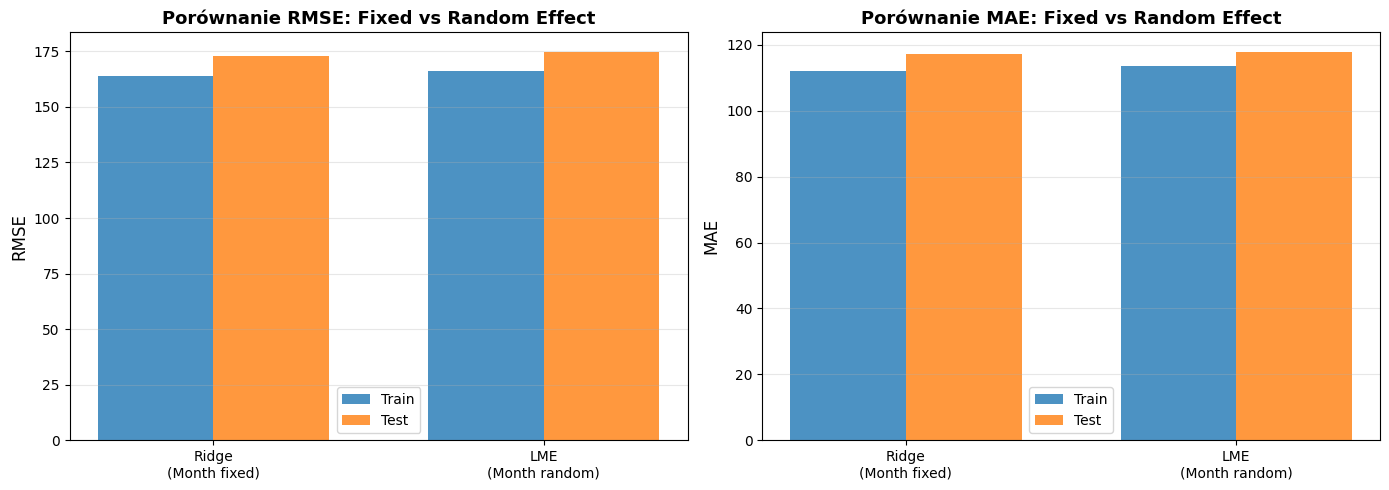

In [24]:
# Porównanie z Ridge (Month jako fixed effect - zmienna kategoryczna)
print("\n" + "="*80)
print("Porównanie: LME vs Ridge")
print("="*80)

# Ridge z Month jako fixed effect (one-hot encoding)
ridge_model = Ridge(alpha=1.0, random_state=42)
scaler_ridge = StandardScaler()

X_tr_ridge = pd.get_dummies(X_tr_lme, columns=['Month'], drop_first=False)
X_te_ridge = pd.get_dummies(X_te_lme, columns=['Month'], drop_first=False)

# Upewnij się że test ma te same kolumny co train
for col in X_tr_ridge.columns:
    if col not in X_te_ridge.columns:
        X_te_ridge[col] = 0
X_te_ridge = X_te_ridge[X_tr_ridge.columns]

start = time.time()
X_tr_scaled = scaler_ridge.fit_transform(X_tr_ridge)
X_te_scaled = scaler_ridge.transform(X_te_ridge)
ridge_model.fit(X_tr_scaled, y_tr_lme)
train_time_ridge = time.time() - start

y_pred_train_ridge = ridge_model.predict(X_tr_scaled)
y_pred_test_ridge = ridge_model.predict(X_te_scaled)

rmse_train_ridge = np.sqrt(mean_squared_error(y_tr_lme, y_pred_train_ridge))
rmse_test_ridge = np.sqrt(mean_squared_error(y_te_lme, y_pred_test_ridge))
mae_train_ridge = mean_absolute_error(y_tr_lme, y_pred_train_ridge)
mae_test_ridge = mean_absolute_error(y_te_lme, y_pred_test_ridge)

# Tabela porównawcza
comparison_lme = pd.DataFrame({
    'Model': ['Ridge (Month fixed)', 'LME (Month random)'],
    'RMSE train': [rmse_train_ridge, rmse_train_lme],
    'RMSE test': [rmse_test_ridge, rmse_test_lme],
    'MAE train': [mae_train_ridge, mae_train_lme],
    'MAE test': [mae_test_ridge, mae_test_lme],
    'Czas [s]': [train_time_ridge, train_time_lme],
    'Overfitting [%]': [
        (rmse_test_ridge/rmse_train_ridge - 1)*100,
        (rmse_test_lme/rmse_train_lme - 1)*100
    ]
})

print("\n", comparison_lme.to_string(index=False))

# Wizualizacja
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
models = ['Ridge\n(Month fixed)', 'LME\n(Month random)']
rmse_train_vals = [rmse_train_ridge, rmse_train_lme]
rmse_test_vals = [rmse_test_ridge, rmse_test_lme]

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, rmse_train_vals, width, label='Train', alpha=0.8)
axes[0].bar(x + width/2, rmse_test_vals, width, label='Test', alpha=0.8)
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].set_title('Porównanie RMSE: Fixed vs Random Effect', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# MAE comparison
mae_train_vals = [mae_train_ridge, mae_train_lme]
mae_test_vals = [mae_test_ridge, mae_test_lme]

axes[1].bar(x - width/2, mae_train_vals, width, label='Train', alpha=0.8)
axes[1].bar(x + width/2, mae_test_vals, width, label='Test', alpha=0.8)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].set_title('Porównanie MAE: Fixed vs Random Effect', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Porównanie wszystkich modeli: Linear, Lasso, Ridge, Huber vs LME

Zestawienie wszystkich modeli z poprzednich zadań z modelem LME:


In [26]:
# Używamy tych samych danych co LME (bez AH, z Month)
X_comparison = pd.get_dummies(X_tr_lme, columns=['Month'], drop_first=False)
X_test_comparison = pd.get_dummies(X_te_lme, columns=['Month'], drop_first=False)

# Upewnij się że test ma te same kolumny
for col in X_comparison.columns:
    if col not in X_test_comparison.columns:
        X_test_comparison[col] = 0
X_test_comparison = X_test_comparison[X_comparison.columns]

# Scaling
scaler_comp = StandardScaler()
X_train_scaled = scaler_comp.fit_transform(X_comparison)
X_test_scaled = scaler_comp.transform(X_test_comparison)

# Słownik z wszystkimi modelami
models_comparison = {
    'Linear Regression': LinearRegression(),
    'Lasso (α=0.1)': Lasso(alpha=0.1, random_state=42, max_iter=10000),
    'Ridge (α=1.0)': Ridge(alpha=1.0, random_state=42),
    'Huber (ε=1.35)': HuberRegressor(epsilon=1.35, max_iter=200),
}

all_results = []

print("="*80)
print("Trenowanie wszystkich modeli...")
print("="*80)

for name, model in models_comparison.items():
    start = time.time()
    model.fit(X_train_scaled, y_tr_lme)
    train_time = time.time() - start
    
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    rmse_train = np.sqrt(mean_squared_error(y_tr_lme, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_te_lme, y_pred_test))
    mae_train = mean_absolute_error(y_tr_lme, y_pred_train)
    mae_test = mean_absolute_error(y_te_lme, y_pred_test)
    
    all_results.append({
        'Model': name,
        'RMSE train': rmse_train,
        'RMSE test': rmse_test,
        'MAE train': mae_train,
        'MAE test': mae_test,
        'Czas [s]': train_time,
        'Overfitting [%]': (rmse_test/rmse_train - 1) * 100
    })
    
    print(f"{name:25} RMSE test: {rmse_test:.2f}, Czas: {train_time:.4f}s")

# Dodaj LME do porównania
all_results.append({
    'Model': 'LME (Month random)',
    'RMSE train': rmse_train_lme,
    'RMSE test': rmse_test_lme,
    'MAE train': mae_train_lme,
    'MAE test': mae_test_lme,
    'Czas [s]': train_time_lme,
    'Overfitting [%]': (rmse_test_lme/rmse_train_lme - 1) * 100
})

# DataFrame z wynikami
df_all_models = pd.DataFrame(all_results)
df_all_models = df_all_models.sort_values('RMSE test')

print("\n" + "="*80)
print("RANKING MODELI (według RMSE test):")
print("="*80)
print(df_all_models.to_string(index=False))
print("\n" + "="*80)


Trenowanie wszystkich modeli...
Linear Regression         RMSE test: 173.02, Czas: 0.0021s
Lasso (α=0.1)             RMSE test: 173.00, Czas: 0.0034s
Ridge (α=1.0)             RMSE test: 173.00, Czas: 0.0011s
Huber (ε=1.35)            RMSE test: 175.52, Czas: 0.0334s

RANKING MODELI (według RMSE test):
             Model  RMSE train  RMSE test  MAE train   MAE test  Czas [s]  Overfitting [%]
     Lasso (α=0.1)  163.811913 172.996565 112.156831 117.186307  0.003381         5.606828
     Ridge (α=1.0)  163.810809 172.999018 112.183781 117.210849  0.001144         5.609037
 Linear Regression  163.810478 173.017161 112.168570 117.201524  0.002077         5.620326
LME (Month random)  166.171943 174.870401 113.585844 117.947342  0.104746         5.234613
    Huber (ε=1.35)  166.824085 175.517267 107.540152 111.507035  0.033386         5.210987



## Wnioski końcowe: Porównanie wszystkich metod

### Ranking modeli (według RMSE test):

1. **Lasso (α=0.1)** - 172.997 najlepszy
2. **Ridge (α=1.0)** - 172.999 (praktycznie identyczny)
3. **Linear Regression** - 173.017 (minimalnie gorszy)
4. **LME (Month random)** - 174.870
5. **Huber (ε=1.35)** - 175.517 (najgorszy)

### Kluczowe obserwacje:

Lasso, Ridge i Linear prawie identyczne:
- Różnica między nimi to tylko ~0.02 RMSE (<0.01%)
- Wszystkie trzy dają praktycznie te same wyniki
- Wniosek: Regularyzacja niewiele pomaga

Huber najgorszy:
- Huber ma najwyższy RMSE test (175.52)
- Huber jest odporny na outliers, ale MY JUŻ USUNĘLIŚMY outliers (-200)
- W czystych danych Huber loss (kombinacja L2 i L1) nie daje przewagi
- Najniższe MAE (111.51) ale najwyższe RMSE - różne błędy niż pozostałe modele
- Wniosek: Huber przydatny TYLKO gdy są outliers, których nie usunęliśmy

LME (Random Effect) nie był optymalny:
- Gorszy od wszystkich modeli liniowych (~2 RMSE różnicy)
- Powód: Month to deterministyczna sezonowość, nie losowa grupa
- Random effect modeluje wariancję, ale miesiące są fixed patterns
- Wolniejszy (0.116s vs <0.02s dla innych)
- Wniosek: Month należy traktować jako fixed effect

Czas treningu:
- Ridge: 0.0019s - najszybszy (closed-form solution)
- Linear: 0.0030s
- Lasso: 0.0055s (iteracyjna optymalizacja)
- Huber: 0.0191s (10× wolniejszy od Ridge)
- LME: 0.1158s (60× wolniejszy od Ridge)

Stabilność (overfitting):
- Wszystkie modele: 5.2-5.6%
- Huber ma najniższy overfitting (5.21%) ale najgorsze wyniki
- Niski overfitting nie sprawia od razu, że model jest dobry (może być underfitting)
- Wniosek: Dane są wystarczająco duże, wszystkie modele są stabilne

Preprocessing był kluczowy:
- Usunięcie AH (wielokolinearność)
- Usunięcie outliers (-200)
- StandardScaler
- Month jako zmienna kategoryczna
- Te kroki sprawiły, że proste modele działają doskonale